# 🧊 Lab 7: Frozen Lake Revisited and Farewell

In this lab, we **return once more to the Frozen Lake** — now larger and more mysterious than before.  
This lab is designed to **tie everything together** through a focused review and practical reflection.


## 🎯 Learning Goals

- Revisit the **core ideas** of **Value Iteration (VI)** and **Policy Iteration (PI)**.  
- Understand how **Monte Carlo** and **Temporal-Difference (TD)** methods extend the same foundation to unknown environments.  
- Gain intuition for how **model-based** and **model-free** reinforcement learning relate.

In [18]:
import gymnasium as gym
import numpy as np
np.set_printoptions(precision=2, suppress=True)
import random
from gymnasium.envs.toy_text.frozen_lake import generate_random_map
from util_frozen import *

In [19]:
# Define a smaller 3x3 map
DESC_5x5 = [
    "SFFFF",
    "FFHFF",
    "FHHFF",
    "FHHFF",
    "FFFFG",
]
env = gym.make("FrozenLake-v1",desc=DESC_5x5,is_slippery=True, render_mode="ansi")
obs, info = env.reset(seed=42)
print(env.render())


SFFFF
FFHFF
FHHFF
FHHFF
FFFFG



In [20]:
# Get the state transition matrix
P, R, absorbing, shape2d, flatmap = build_frozenlake_transitions(DESC_5x5, is_slippery=True)
T_per_action = [P[:, a, :] for a in range(4)] 
P_all = np.array([T_per_action[0], T_per_action[1], T_per_action[2], T_per_action[3]])

In [21]:
n_states = 25
Reward = np.zeros((n_states,), dtype = int) 
Reward[-1] = 1
gamma = 0.9

## 🗺️ 第一部分 – 重新审视冰冻湖问题

首先，我们重新实现 **价值迭代（value iteration）** 方法，该方法将
策略评估（evaluation）与策略改进（improvement）合并为一个更新规则：

$$
V_{k+1}(s) \;=\; \max_a \Big[ R(s) + \gamma \sum_{s'} P(s'|s,a) \, V_k(s') \Big].
$$

当价值函数收敛之后，我们通过在每个状态中选择使上述表达式取得最大值的动作，
来提取最优策略：

$$
\pi^*(s) = \arg\max_a \Big[ R(s) + \gamma \sum_{s'} P(s'|s,a) V^*(s') \Big].
$$

In [ ]:
# Initialize the original value 
V_0 = np.zeros_like(Reward, dtype=float)
V_new = np.zeros_like(V_0, dtype=float)
NUM_ITER = 150
NUM_ACT = P_all.shape[0]
for i_step in np.arange(NUM_ITER):
    for i_state in np.arange(n_states):
        action_values = np.zeros((4,), dtype=float)

        # Bellman optimality backup for each action
        for i_action in np.arange(NUM_ACT):
            action_values[i_action] = Reward[i_state] + gamma * np.sum(P_all[i_action, i_state, :] * V_0[:])

        V_new[i_state] = np.max(action_values)
        
    V_0 = V_new.copy()

    
    if np.mod(i_step, 10) ==0:
        print(f"iter:{i_step}, values: {V_new}")

iter:0, values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1.]
iter:10, values: [0.   0.02 0.07 0.27 0.35 0.01 0.   0.   0.56 0.78 0.02 0.   0.   1.2
 1.74 0.09 0.   0.   2.26 3.53 0.29 0.63 1.54 3.53 6.86]
iter:20, values: [0.13 0.24 0.53 1.14 1.28 0.12 0.1  0.   1.61 1.96 0.22 0.   0.   2.52
 3.23 0.48 0.   0.   3.85 5.32 1.02 1.55 2.83 5.32 8.91]
iter:30, values: [0.33 0.49 0.89 1.66 1.82 0.31 0.23 0.   2.16 2.53 0.44 0.   0.   3.12
 3.86 0.78 0.   0.   4.5  6.   1.46 2.04 3.4  6.   9.62]
iter:40, values: [0.46 0.64 1.06 1.88 2.04 0.43 0.31 0.   2.38 2.76 0.58 0.   0.   3.35
 4.09 0.94 0.   0.   4.74 6.24 1.65 2.24 3.62 6.24 9.87]
iter:50, values: [0.52 0.7  1.13 1.96 2.12 0.49 0.36 0.   2.46 2.84 0.64 0.   0.   3.43
 4.18 1.01 0.   0.   4.82 6.33 1.73 2.32 3.7  6.33 9.95]
iter:60, values: [0.54 0.73 1.16 1.99 2.15 0.51 0.37 0.   2.49 2.87 0.66 0.   0.   3.46
 4.21 1.03 0.   0.   4.85 6.36 1.76 2.35 3.73 6.36 9.98]
iter:70, values: [0.55 0.74 1.17 2.  

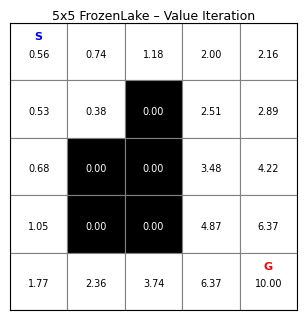

In [23]:
render_value_grid(V_new, DESC_5x5, title="5x5 FrozenLake – Value Iteration")

接下来，我们尝试重新实现 **截断（修改的）策略迭代（Truncated / Modified Policy Iteration）** 算法，其中我们在 **部分策略评估（partial policy evaluation）** 和 **策略改进（policy improvement）** 之间交替进行：

$$
V^{(j+1)}(s) \;=\; R(s) \;+\; \gamma \sum_{s'} P(s' \mid s, \pi_k(s))\, V^{(j)}(s'),
\quad j = 0,1,\dots,m-1,
$$

随后执行策略改进步骤：

$$
\pi_{k+1}(s) \;=\; \arg\max_{a} \Big[ \, R(s) \;+\; \gamma \sum_{s'} P(s' \mid s, a)\, V^{(m)}(s') \, \Big].
$$


In [ ]:
# Initialize an original value 
V_0 = np.zeros_like(Reward, dtype=float)
V_new = np.zeros_like(V_0, dtype=float)
# Initialize an original policy 
PI_0 = np.zeros_like(Reward)
PI_new = np.zeros_like(Reward)
NUM_ITER = 40
NUM_ACT = P_all.shape[0]
NUM_PE = 10

for i_step in np.arange(NUM_ITER):
    for i_VI in np.arange(NUM_PE): 
        
    #### Your time to work on it ######
        
        for i_state in np.arange(n_states):
            
            chosen_action = int(PI_0[i_state])
            V_new[i_state] = Reward[i_state] + gamma * np.sum(P_all[chosen_action, i_state, :] * V_0[:])
           
        V_0 = V_new.copy()
            
    for i_state in np.arange(n_states):
        action_values = np.zeros((4,), dtype=float)
        for i_action in np.arange(NUM_ACT):
            action_values[i_action] = Reward[i_state] + gamma * np.sum(P_all[i_action, i_state, :] * V_0[:])
        PI_new[i_state] = int(np.argmax(action_values))
        
     #####
         
    V_0 = V_new.copy()
    PI_0 = PI_new.copy()
    print(f"iter:{i_step}, values: {V_new}, policy: {PI_new}")

iter:0, values: [0.   0.   0.   0.   0.06 0.   0.   0.   0.   0.18 0.   0.   0.   0.
 0.6  0.   0.   0.   0.   2.   0.   0.   0.   0.   6.51], policy: [0 0 0 1 2 0 0 0 1 2 0 0 0 1 2 0 0 0 1 2 0 0 0 1 0]
iter:1, values: [0.   0.   0.   0.41 0.75 0.   0.   0.   0.75 1.23 0.   0.   0.   1.4
 2.39 0.   0.   0.   2.44 4.64 0.   0.   0.   3.68 8.78], policy: [0 0 1 2 2 0 0 0 2 2 0 0 0 2 1 0 0 0 2 1 0 0 1 2 0]
iter:2, values: [0.   0.   0.38 1.32 1.44 0.   0.   0.   1.84 2.11 0.   0.   0.   2.91
 3.69 0.   0.   0.   4.35 5.9  0.   0.   2.49 5.9  9.58], policy: [0 1 2 2 2 0 0 0 2 1 0 0 0 2 1 0 0 0 2 1 0 1 1 2 0]
iter:3, values: [0.   0.24 0.76 1.81 1.97 0.   0.07 0.   2.32 2.7  0.   0.   0.   3.3
 4.05 0.   0.   0.   4.7  6.21 0.   1.37 3.23 6.21 9.85], policy: [1 2 3 2 2 1 0 0 2 1 0 0 0 2 1 0 0 0 2 1 1 1 1 2 0]
iter:4, values: [0.3  0.53 1.05 1.94 2.11 0.22 0.21 0.   2.45 2.83 0.37 0.   0.   3.42
 4.17 0.74 0.   0.   4.81 6.32 1.49 2.12 3.59 6.32 9.95], policy: [3 3 3 2 2 0 0 0 2 1 0 0 0 2 1 

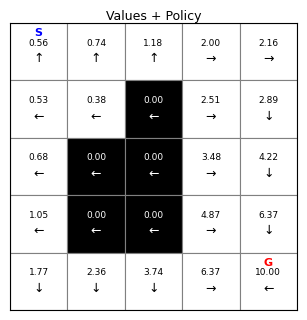

In [25]:
render_value_and_policy_grid(V_new, PI_new, DESC_5x5, title="Values + Policy")

# 🍀 第二部分 — 基于 $ε$-贪心策略的蒙特卡洛（MC）控制

在这一部分，我们实现 **蒙特卡洛 $ε$-贪心控制（Monte Carlo $ε$-Greedy Control）**，
它是 **蒙特卡洛探索起点（Monte Carlo Exploring Starts）** 的一种实用变体，
**不需要** 特殊的起始状态。

---

## 📘 算法：MC $ε$-贪心控制

**目标：** 通过采样和 $ε$-贪心策略改进，搜索最优策略 $π^*$ 和动作价值函数 $q^*$。

### 初始化
- 对所有 $(s, a)$，初始化策略 $\pi_0(a | s)$ 和动作价值函数 $q(s, a)$。  
- 初始化 `R(s,a) = 0`，`N(s,a) = 0`。  
- 选择一个探索参数 $ε \in (0, 1]$。

In [26]:
import numpy as np

def epsilon_adjust_action(action, n_actions, epsilon):
    """
    With probability ε, replace the chosen action with a random one (exploration);
    otherwise keep the same action (exploitation).

    Parameters
    ----------
    action : int
        The greedy or proposed action.
    n_actions : int
        Total number of possible actions.
    epsilon : float
        Exploration probability (0 ≤ ε ≤ 1).

    Returns
    -------
    int : possibly adjusted action
    """
    if np.random.rand() < epsilon:
        # explore: choose any action except the current one (optional)
        alt_actions = [a for a in range(n_actions) if a != action]
        return np.random.choice(alt_actions)
    else:
        # exploit: keep the current action
        return action


In [27]:
import numpy as np

n_states = env.observation_space.n     # total number of states
n_actions = env.action_space.n         # total number of actions
# Action–value function q(s,a)
Q = np.zeros((n_states, n_actions), dtype=float)
Q[-1,:] =10
# Cumulative returns R(s,a)
Returns = np.zeros_like(Q, dtype=float)
# Visit counts N(s,a)
Num = np.zeros_like(Q, dtype=float)
min_epsilon = 0.1
epsilon_decay = 0.95
max_steps = 100
# Exploration parameter
epsilon = 1

# Deterministic greedy policy: one action per state
# Initially arbitrary since all Q=0
pi = np.zeros(n_states, dtype=int)

print("Initialization complete:")
print(f"States: {n_states}, Actions: {n_actions}, ε = {epsilon}")


Initialization complete:
States: 25, Actions: 4, ε = 1


### 对于每一条回合（episode）

1. **生成回合（Episode Generation）**  
   - 选择一个初始状态–动作对 $(s_0, a_0)$，或者直接从默认初始状态开始。  
   - 按照**当前的 $ε$-贪心策略** $\pi$ 生成一个长度为 $T$ 的回合：  
     $ (s_0, a_0, r_1, s_1, a_1, \dots, s_{T-1}, a_{T-1}, r_T) $。

2. **初始化本回合的回报：** $G = 0$

3. **反向回报计算（Backward Return Computation）**  
   对于回合中的每一步，$t = T − 1, T − 2, \ldots, 0$，执行以下操作：
   $$
   g \leftarrow \gamma g + r_{t+1}
   $$
   $$
   \text{R}(s_t, a_t) \leftarrow \text{R}(s_t, a_t) + g
   $$
   $$
   \text{N}(s_t, a_t) \leftarrow \text{N}(s_t, a_t) + 1
   $$
   $$
   q(s_t, a_t) \leftarrow \frac{\text{R}(s_t, a_t)}{\text{N}(s_t, a_t)}
   $$

4. **策略改进（Policy Improvement）**
   - 令 $ a^* = \arg\max_a q(s_t, a) $。  
   - 将策略 $\pi$ 更新为关于 $q$ 的 $ε$-贪心策略：

     $$
     \pi(a|s_t) =
     \begin{cases}
     1 - \varepsilon + \dfrac{\varepsilon}{|\mathcal{A}(s_t)|}, & a = a^* \\\\
     \dfrac{\varepsilon}{|\mathcal{A}(s_t)|}, & a \neq a^*
     \end{cases}
     $$

iter: 0, epsilon = 0.95 


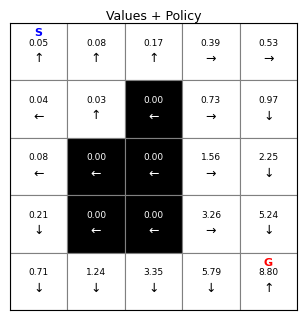

iter: 1, epsilon = 0.9025 


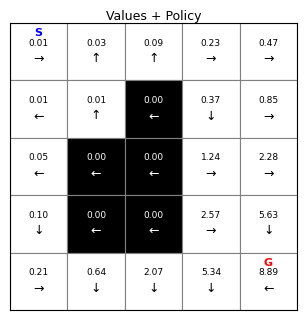

iter: 2, epsilon = 0.8573749999999999 


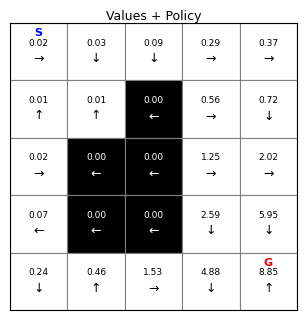

iter: 3, epsilon = 0.8145062499999999 


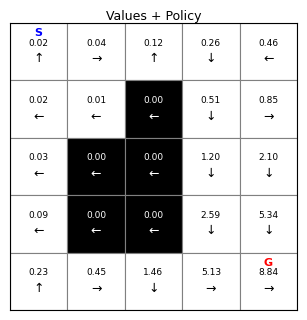

iter: 4, epsilon = 0.7737809374999999 


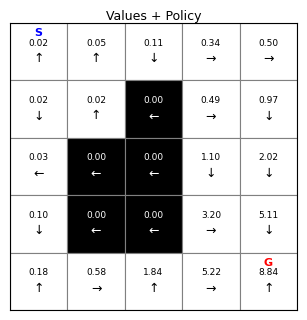

iter: 5, epsilon = 0.7350918906249998 


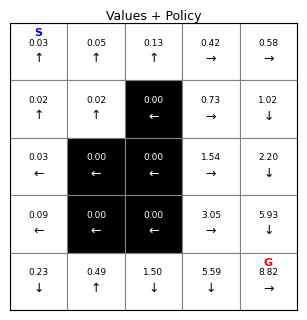

iter: 6, epsilon = 0.6983372960937497 


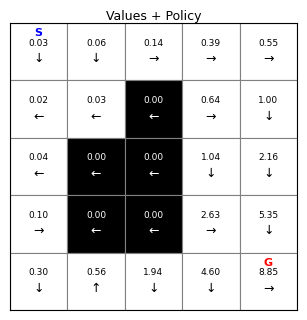

iter: 7, epsilon = 0.6634204312890623 


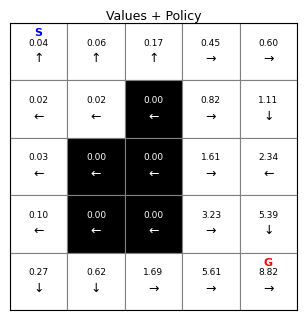

iter: 8, epsilon = 0.6302494097246091 


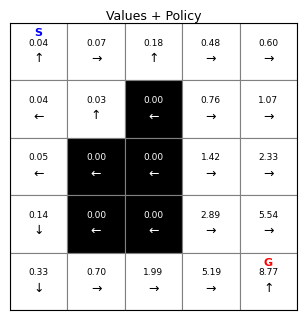

iter: 9, epsilon = 0.5987369392383786 


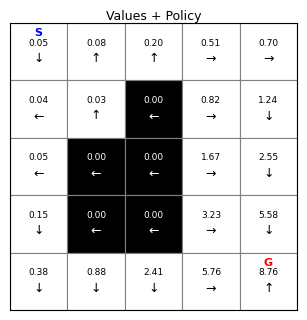

iter: 10, epsilon = 0.5688000922764596 


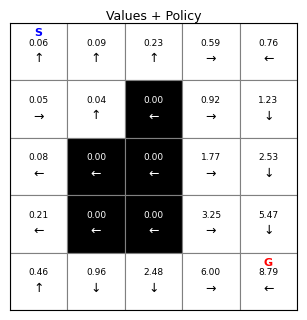

iter: 11, epsilon = 0.5403600876626365 


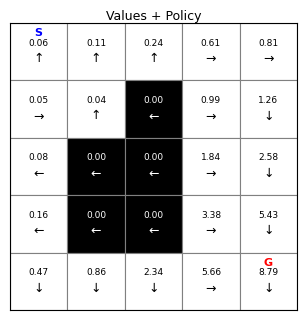

iter: 12, epsilon = 0.5133420832795047 


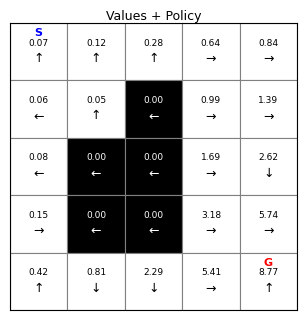

iter: 13, epsilon = 0.48767497911552943 


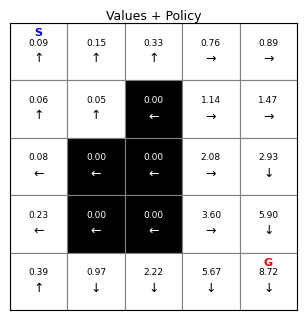

iter: 14, epsilon = 0.46329123015975293 


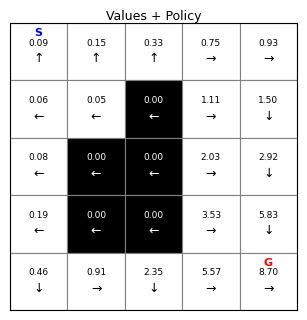

iter: 15, epsilon = 0.44012666865176525 


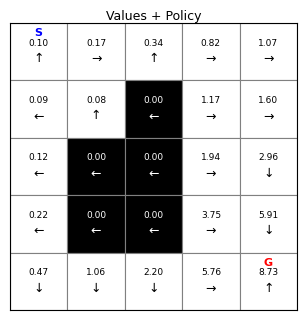

iter: 16, epsilon = 0.41812033521917696 


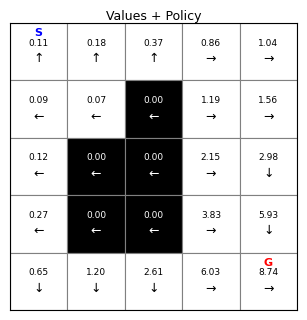

iter: 17, epsilon = 0.3972143184582181 


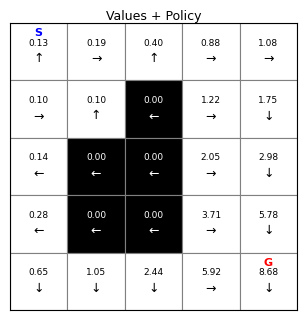

iter: 18, epsilon = 0.37735360253530714 


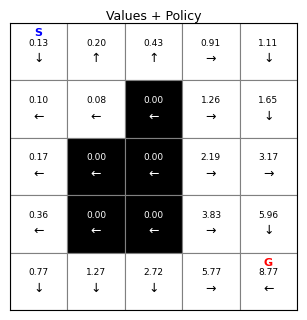

iter: 19, epsilon = 0.35848592240854177 


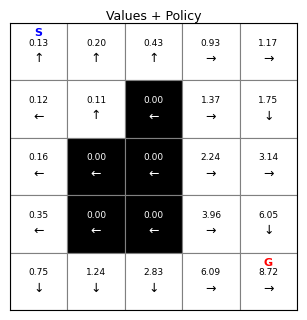

iter: 20, epsilon = 0.34056162628811465 


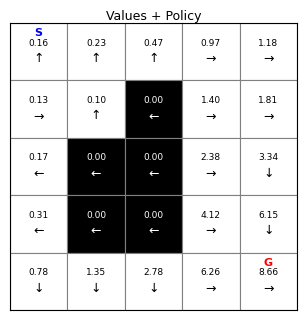

iter: 21, epsilon = 0.3235335449737089 


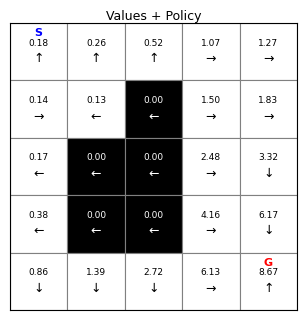

iter: 22, epsilon = 0.30735686772502346 


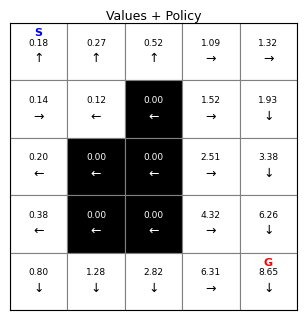

iter: 23, epsilon = 0.2919890243387723 


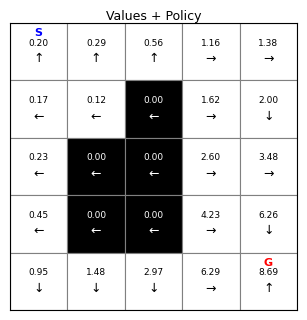

iter: 24, epsilon = 0.27738957312183365 


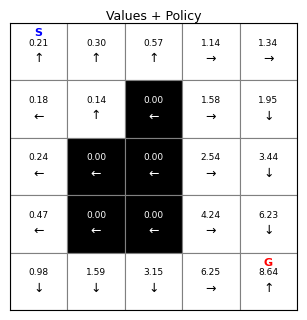

iter: 25, epsilon = 0.263520094465742 


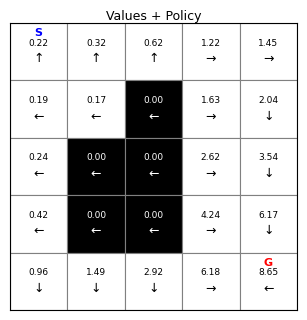

iter: 26, epsilon = 0.25034408974245487 


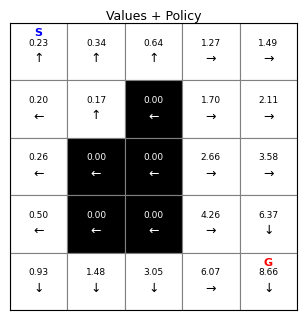

iter: 27, epsilon = 0.2378268852553321 


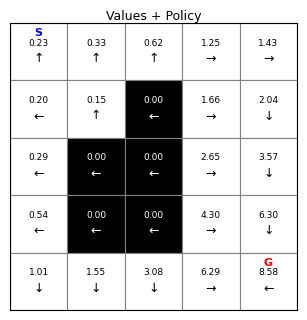

iter: 28, epsilon = 0.2259355409925655 


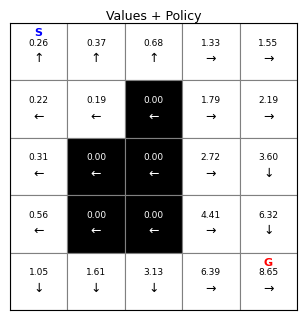

iter: 29, epsilon = 0.2146387639429372 


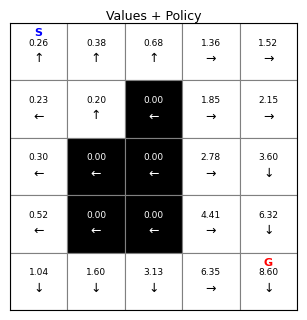

iter: 30, epsilon = 0.20390682574579033 


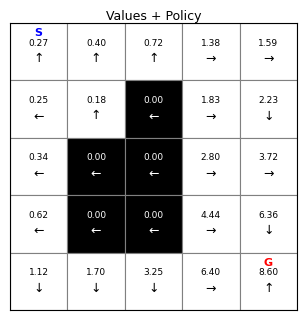

iter: 31, epsilon = 0.1937114844585008 


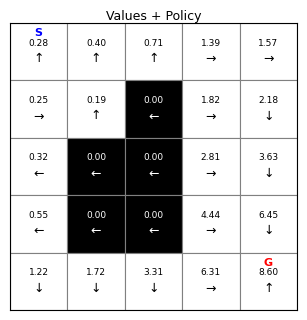

iter: 32, epsilon = 0.18402591023557577 


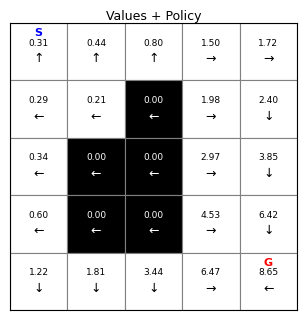

iter: 33, epsilon = 0.17482461472379698 


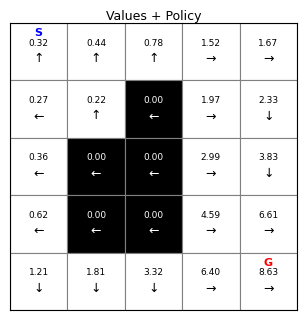

iter: 34, epsilon = 0.16608338398760714 


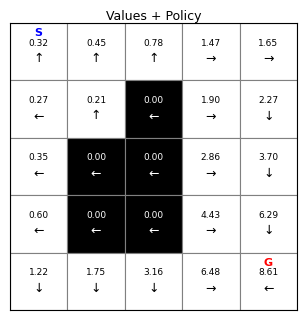

iter: 35, epsilon = 0.15777921478822676 


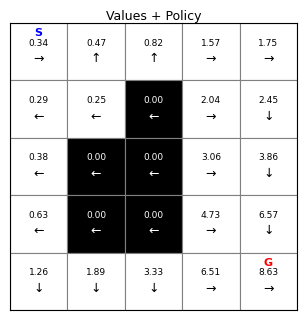

iter: 36, epsilon = 0.14989025404881542 


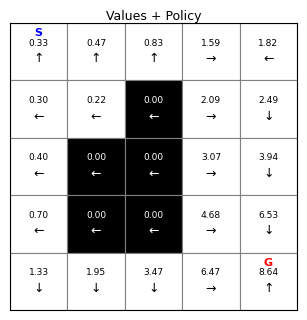

iter: 37, epsilon = 0.14239574134637464 


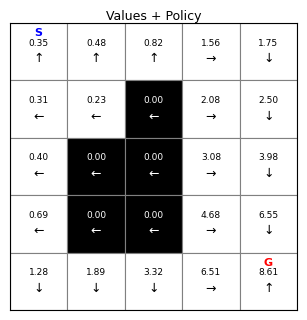

iter: 38, epsilon = 0.1352759542790559 


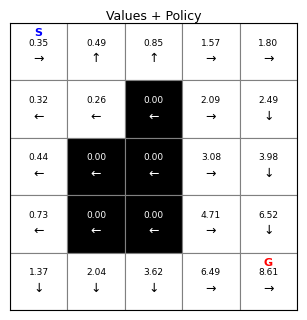

iter: 39, epsilon = 0.1285121565651031 


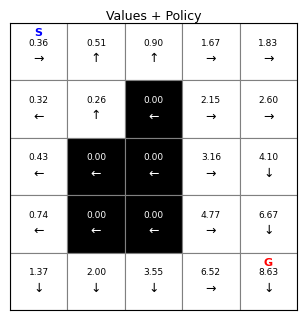

iter: 40, epsilon = 0.12208654873684793 


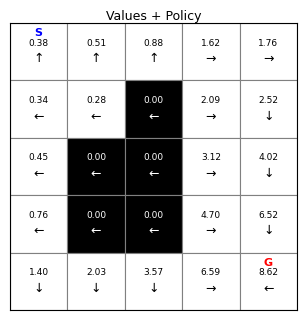

iter: 41, epsilon = 0.11598222130000553 


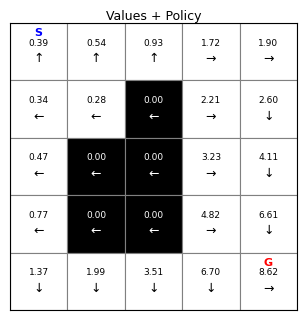

iter: 42, epsilon = 0.11018311023500525 


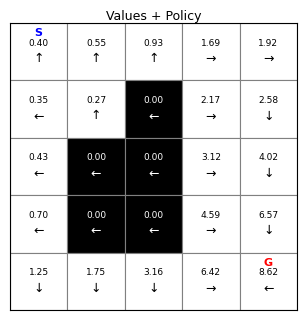

iter: 43, epsilon = 0.10467395472325498 


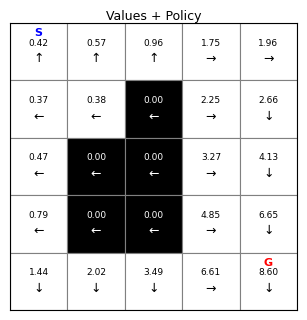

iter: 44, epsilon = 0.1 


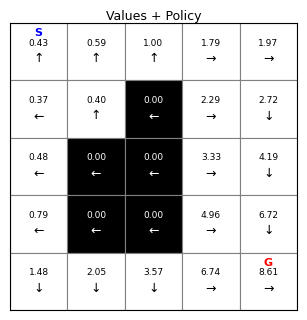

iter: 45, epsilon = 0.1 


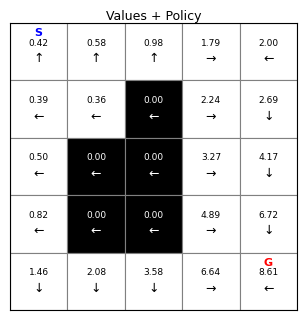

iter: 46, epsilon = 0.1 


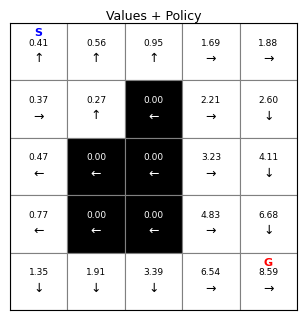

iter: 47, epsilon = 0.1 


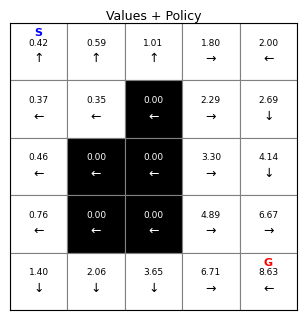

iter: 48, epsilon = 0.1 


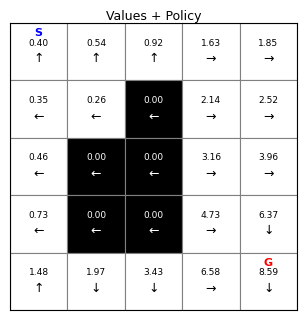

iter: 49, epsilon = 0.1 


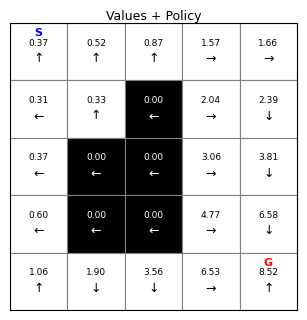

iter: 50, epsilon = 0.1 


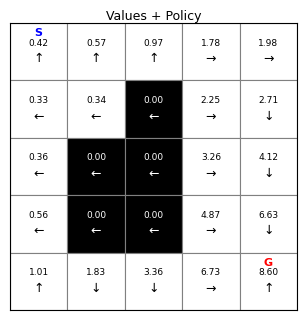

iter: 51, epsilon = 0.1 


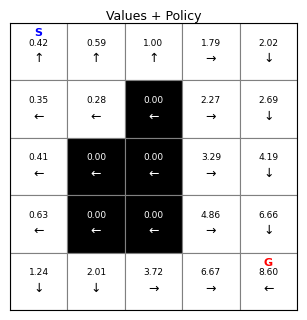

iter: 52, epsilon = 0.1 


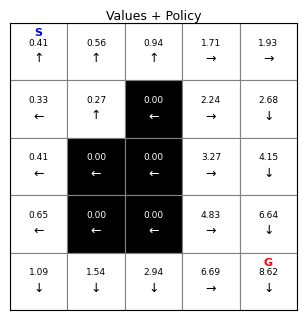

iter: 53, epsilon = 0.1 


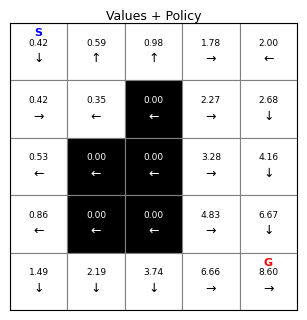

iter: 54, epsilon = 0.1 


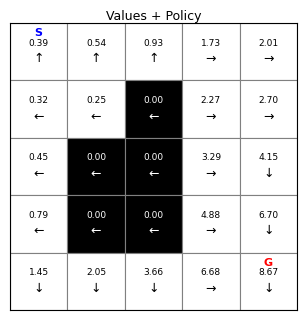

iter: 55, epsilon = 0.1 


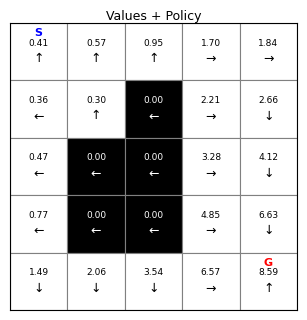

iter: 56, epsilon = 0.1 


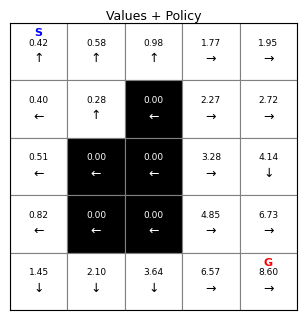

iter: 57, epsilon = 0.1 


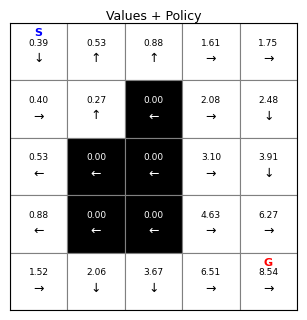

iter: 58, epsilon = 0.1 


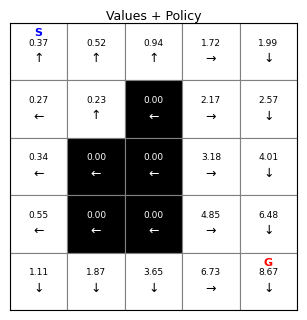

iter: 59, epsilon = 0.1 


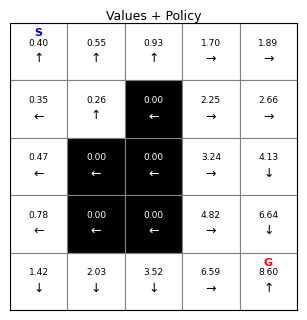

iter: 60, epsilon = 0.1 


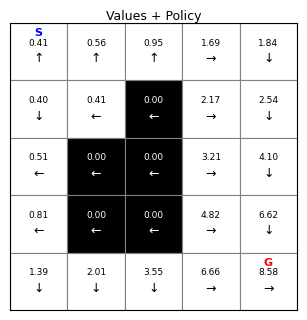

iter: 61, epsilon = 0.1 


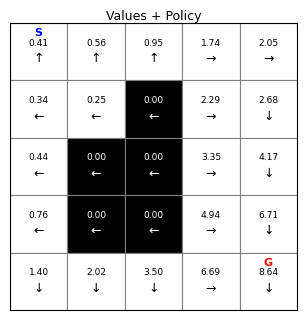

iter: 62, epsilon = 0.1 


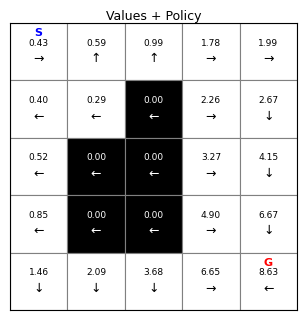

iter: 63, epsilon = 0.1 


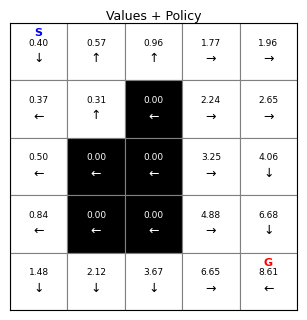

iter: 64, epsilon = 0.1 


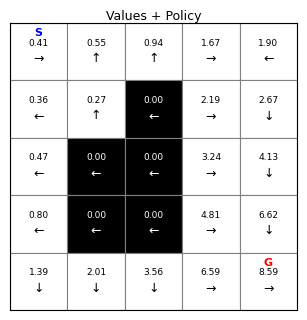

iter: 65, epsilon = 0.1 


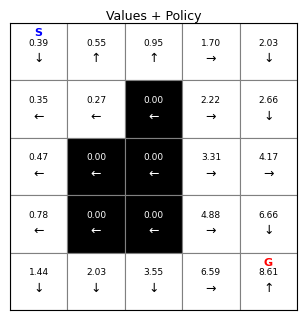

iter: 66, epsilon = 0.1 


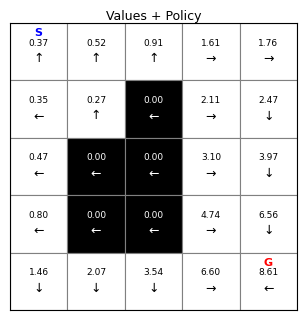

iter: 67, epsilon = 0.1 


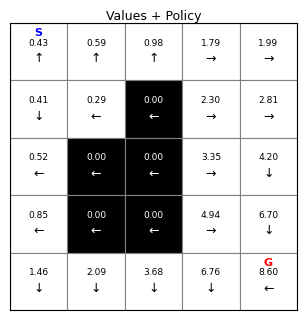

iter: 68, epsilon = 0.1 


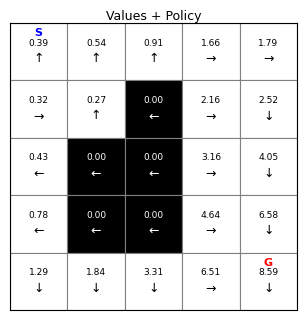

iter: 69, epsilon = 0.1 


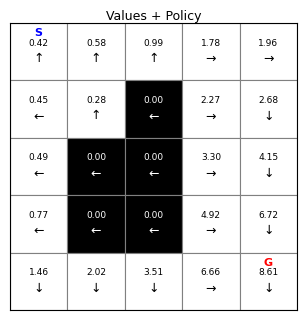

iter: 70, epsilon = 0.1 


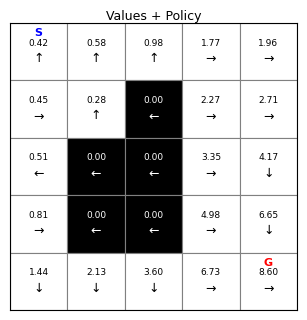

iter: 71, epsilon = 0.1 


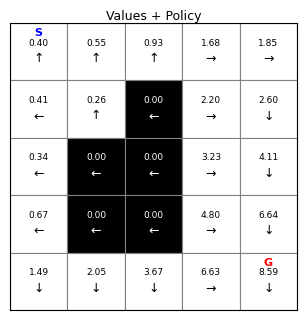

iter: 72, epsilon = 0.1 


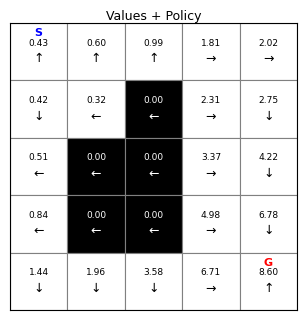

iter: 73, epsilon = 0.1 


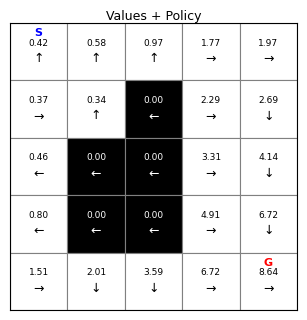

iter: 74, epsilon = 0.1 


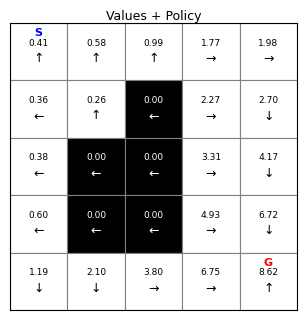

iter: 75, epsilon = 0.1 


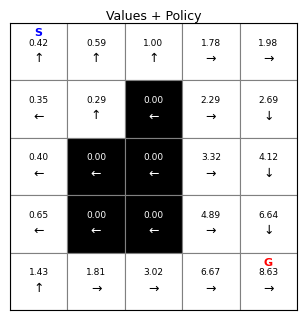

iter: 76, epsilon = 0.1 


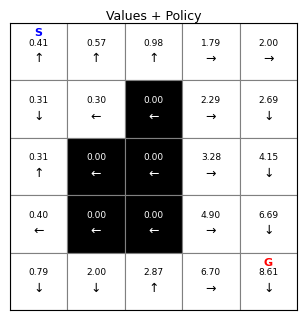

iter: 77, epsilon = 0.1 


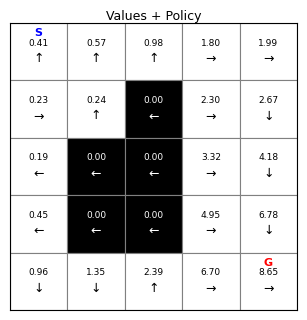

iter: 78, epsilon = 0.1 


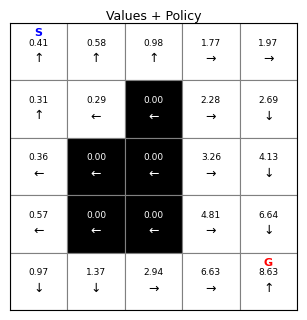

iter: 79, epsilon = 0.1 


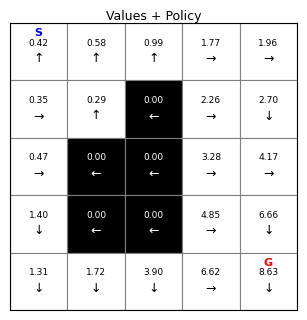

iter: 80, epsilon = 0.1 


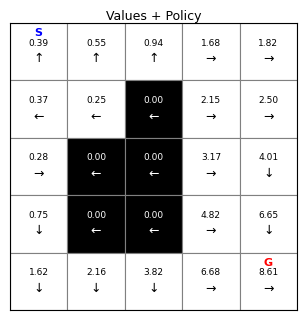

iter: 81, epsilon = 0.1 


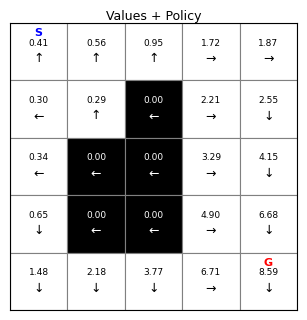

iter: 82, epsilon = 0.1 


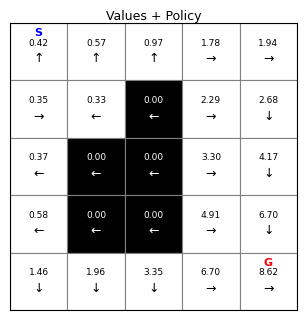

iter: 83, epsilon = 0.1 


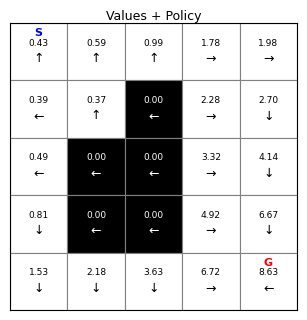

iter: 84, epsilon = 0.1 


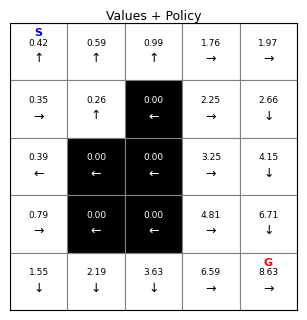

iter: 85, epsilon = 0.1 


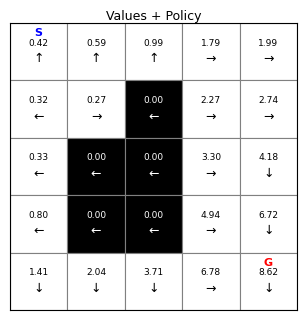

iter: 86, epsilon = 0.1 


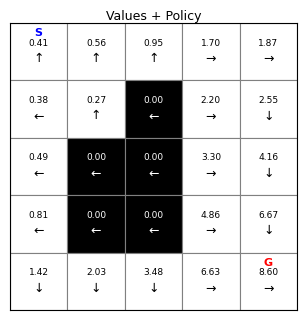

iter: 87, epsilon = 0.1 


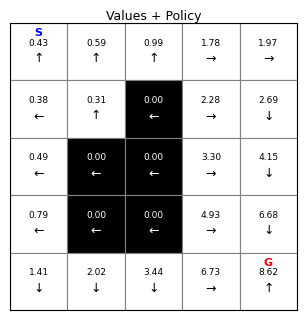

iter: 88, epsilon = 0.1 


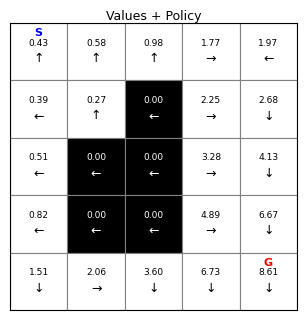

iter: 89, epsilon = 0.1 


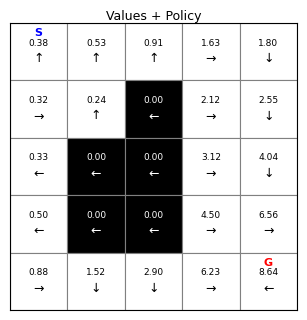

iter: 90, epsilon = 0.1 


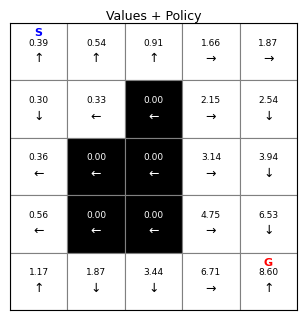

iter: 91, epsilon = 0.1 


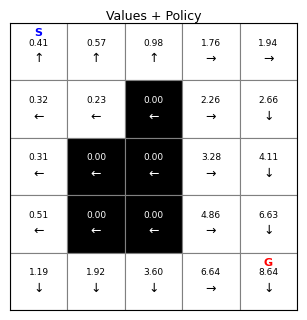

iter: 92, epsilon = 0.1 


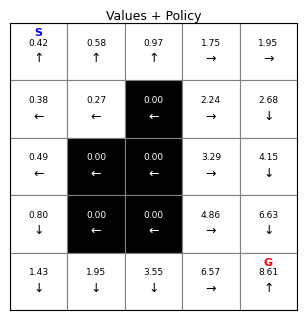

iter: 93, epsilon = 0.1 


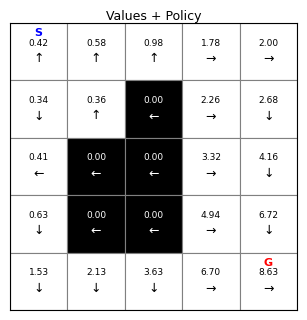

iter: 94, epsilon = 0.1 


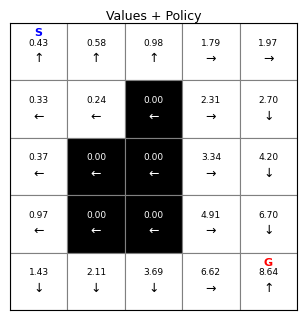

iter: 95, epsilon = 0.1 


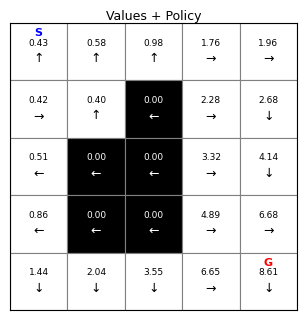

iter: 96, epsilon = 0.1 


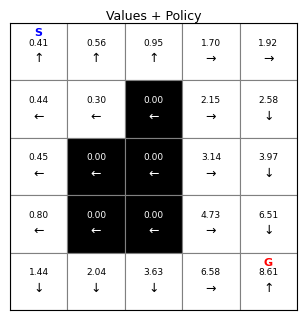

iter: 97, epsilon = 0.1 


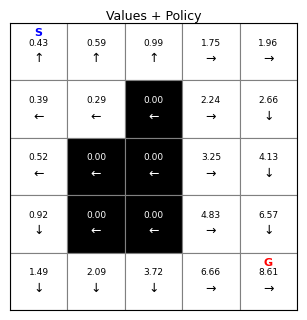

iter: 98, epsilon = 0.1 


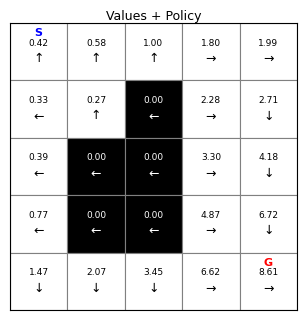

iter: 99, epsilon = 0.1 


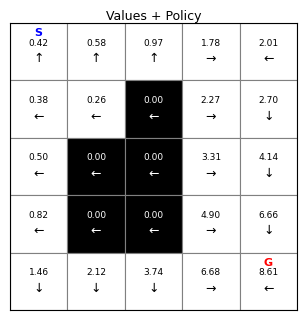

In [ ]:
num_episodes = 20000  # Here, one episode is too short, we do multiple episodes

for i_ter in np.arange(100):
    Q        = np.zeros((n_states, n_actions), dtype=float)
    Returns  = np.zeros_like(Q)
    Num      = np.zeros_like(Q)

    # Decay the epsilon coefficient to encourage exploration in the beginning
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    
    for ep in range(num_episodes):
        s, _ = env.reset()
        states, actions, rewards = [s], [], []
        
        done, steps = False, 0
        while steps < max_steps:
            a = epsilon_adjust_action(pi[s], n_actions, epsilon)
            # a slight modification on the environment to make the result match
            if done:
                s_next = s 
                r = Reward[s]
                actions.append(a); rewards.append(r); states.append(s_next) 
            else: 
                s_next, r, term, trunc, _ = env.step(a)
                done = bool(term or trunc)
                actions.append(a); rewards.append(r); states.append(s_next)    
                s = s_next
            
            steps += 1
    
        G = 0.0
        T = len(actions) 
        for t in range(T-1, -1, -1):
            s_t, a_t = states[t], actions[t]
            G = rewards[t] + gamma * G
            Returns[s_t, a_t] = Returns[s_t, a_t] + G
            Num[s_t, a_t] += 1.0
            Q[s_t, a_t] = Returns[s_t, a_t] / Num[s_t, a_t]

    # Policy improvement
    pi = np.argmax(Q, axis=1)
    
    print(f"iter: {i_ter}, epsilon = {epsilon} ")
    render_value_and_policy_grid(Q.max(axis=1), pi, DESC_5x5, title="Values + Policy")